# Notebook14 — Dynamic Cellular State Trajectory Simulation

---

## Goal of Notebook14

Notebook14 introduces temporal dynamics into the virtual CHO-cell digital twin simulator.

Previous notebooks modeled:

- clone productivity
- process optimization
- glycosylation-quality coupling
- process burden realism
- multi-omics latent states

However, those notebooks still treated clone states as mostly static snapshots.

Real CHO cells are dynamic systems.

During culture progression:

- secretion burden accumulates
- ER stress changes
- metabolic pressure evolves
- glycosylation drifts
- productivity adapts or collapses
- omics programs transition
- process interventions alter trajectories

Notebook14 introduces dynamic temporal evolution of cellular states.

---

# Core Concept

Previous notebooks modeled:

clone + process → latent state → outcome

Notebook14 now models:

clone + process + time → evolving latent state trajectory → dynamic outcome

This moves the project closer to a true digital twin architecture.

---

# Why dynamic trajectories matter

Real bioprocesses evolve continuously.

A clone that appears healthy at day 3 may:

- collapse at day 10
- recover after intervention
- drift metabolically
- accumulate stress
- alter glycosylation behavior

Static prediction is insufficient for capturing these behaviors.

Notebook14 introduces pseudo-time cellular evolution.

---

# What this notebook simulates

Notebook14 simulates:

## 1. Dynamic burden accumulation

- secretion burden
- metabolic overflow
- oxidative stress
- ER stress

all evolve through pseudo-time.

---

## 2. Dynamic productivity adaptation

Productivity may:

- remain stable
- improve transiently
- slowly decay
- abruptly collapse

depending on hidden cellular state.

---

## 3. Dynamic glycosylation drift

Galactosylation and sialylation states may drift due to:

- stress
- nutrient depletion
- metabolic burden
- intervention effects

---

## 4. Dynamic intervention response

Process interventions can alter trajectories.

Examples:

- temperature shift
- perfusion rescue
- adaptive feeding

These may stabilize or rescue cellular states.

---

# Digital Twin Significance

Notebook14 is the first notebook that models:

state evolution through time.

This transforms the simulator from:

static predictive simulator

into:

dynamic process-aware virtual CHO-cell system.

This is a foundational step toward:

- reinforcement learning
- self-driving laboratories
- adaptive process control
- closed-loop optimization
- autonomous bioprocessing

---

# Important Interpretation

The trajectories in this notebook are synthetic but biologically motivated.

The goal is not exact mechanistic kinetics.

The goal is to create biologically coherent temporal state evolution that can later support:

- RL environments
- adaptive control systems
- empirical calibration
- real digital-twin development

## Section 1 — Import libraries

This section loads the libraries required for:

- numerical simulation
- temporal trajectory generation
- visualization
- clustering
- dimensionality reduction

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## Section 2 — Load Notebook13 multi-omics latent-state output

Notebook14 builds directly on Notebook13.

Notebook13 created:

- transcriptomic programs
- proteomic programs
- metabolomic programs
- latent omics states
- cellular archetypes

Notebook14 now evolves those biological states through pseudo-time.

In [2]:
# --------------------------------------------------
# Section 2 — Load Notebook13 output
# --------------------------------------------------

def find_project_root(start=None):
    if start is None:
        start = Path.cwd().resolve()

    start = Path(start).resolve()

    for p in [start, *start.parents]:
        if (p / "data" / "synthetic").exists():
            return p

    raise FileNotFoundError("Could not find project root")


ROOT = find_project_root()

scenario = "legacy"
n_clones = 5000

INPUT_PATH = (
    ROOT /
    "data" /
    "synthetic" /
    "omics" /
    f"notebook13_multiomics_latent_state_{n_clones}_{scenario}.csv"
)

df = pd.read_csv(INPUT_PATH)

print(df.shape)

display(df.head())

(92, 93)


,clone_id,process_condition,pareto_rank,candidate_archetype,weighted_multiobj_score,obj_productivity,obj_stability,obj_quality,obj_risk_safety,obj_rescue_value,...,met_nutrient_pressure,met_overflow_burden,omics_latent_1,omics_latent_2,omics_latent_3,omics_latent_4,cellular_state,cellular_archetype,tsne_1,tsne_2
0,CLONE_4625,stress_minimized,1.0,Rescue-value,0.832599,1.000000,0.830653,0.698502,0.612287,1.000000,...,0.518487,0.555266,4.402637,-0.910681,-0.404721,3.186541,0,Quality-Adapted,7.685490,-7.108506
1,CLONE_4878,stress_minimized,2.0,Balanced,0.730900,0.796817,0.692042,0.663813,0.731984,0.776958,...,0.393058,0.366546,2.675861,-2.601021,1.133786,1.362528,0,Quality-Adapted,5.410643,-1.035339
2,CLONE_3895,mild_temp_shift,3.0,Risk-safe,0.603442,0.011834,0.822675,0.986077,1.000000,0.388383,...,0.144979,0.099176,-4.845263,0.200871,0.349792,0.838802,3,Balanced-Resilient,-0.692288,8.589075
3,CLONE_3895,balanced_feed,4.0,Quality-led,0.601918,0.011834,0.822675,0.989642,0.983893,0.388383,...,0.145543,0.128355,-4.768517,0.790040,-1.619075,1.681215,3,Balanced-Resilient,-0.509352,9.235153
4,CLONE_3007,stress_minimized,5.0,Stability-led,0.601847,0.000540,0.992249,0.926534,0.967398,0.264918,...,0.162880,0.117508,-2.388811,-0.813747,-2.461280,-1.025476,3,Balanced-Resilient,2.135555,4.627896


## Section 3 — Select trajectory initialization variables

This section selects the latent biological variables that will evolve dynamically through pseudo-time.

These variables represent:

- productivity
- burden
- stress
- glycosylation
- metabolic state
- rescue potential

These become the evolving cellular state variables.

In [3]:
# --------------------------------------------------
# Section 3 — Initialize dynamic state variables
# --------------------------------------------------

trajectory_vars = [
    "productivity_signal",
    "integrated_burden",
    "oxidative_stress",
    "er_stress_burden",
    "stress_failure_risk",
    "process_galactosylation_level",
    "process_sialylation_capacity",
    "met_overflow_burden",
    "rescue_potential_score",
]

missing = [c for c in trajectory_vars if c not in df.columns]

if missing:
    raise KeyError(f"Missing trajectory columns: {missing}")

display(df[trajectory_vars].describe())

,productivity_signal,integrated_burden,oxidative_stress,er_stress_burden,stress_failure_risk,process_galactosylation_level,process_sialylation_capacity,met_overflow_burden,rescue_potential_score
count,9.200000e+01,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000
mean,3.727049e-07,0.304636,0.341646,0.324108,0.320337,0.705708,0.660519,0.278334,0.604857
std,7.524082e-07,0.102507,0.115686,0.134248,0.123528,0.186275,0.204430,0.109755,0.071143
min,2.498445e-08,0.056264,0.065446,0.000000,0.000000,0.250485,0.288012,0.009155,0.425795
25%,8.950082e-08,0.221207,0.264259,0.232144,0.244631,0.596822,0.470016,0.197772,0.558909
50%,1.937304e-07,0.308754,0.342485,0.321828,0.318254,0.723012,0.652346,0.282303,0.607900
75%,3.636152e-07,0.380547,0.429701,0.429851,0.403930,0.840422,0.804557,0.352445,0.652658
max,5.537450e-06,0.554353,0.654960,0.668067,0.588827,1.000000,1.000000,0.555266,0.794791


## Section 4 — Define pseudo-time trajectory parameters

This section defines the trajectory simulation settings.

Pseudo-time does not represent exact culture days.

Instead, it represents relative cellular evolution stages.

The notebook simulates:

- burden accumulation
- stress amplification
- productivity adaptation
- glycosylation drift
- intervention stabilization

In [4]:
# --------------------------------------------------
# Section 4 — Trajectory parameters
# --------------------------------------------------

rng = np.random.default_rng(42)

n_steps = 15

trajectory_records = []

print("Pseudo-time steps:", n_steps)

Pseudo-time steps: 15


## Section 5 — Simulate dynamic cellular trajectories

This section generates evolving cellular trajectories.

Each clone-process candidate evolves through pseudo-time.

The evolution rules are biologically inspired:

- burden tends to accumulate
- stress tends to increase
- productivity may decline under burden
- rescue potential may stabilize trajectories
- glycosylation may drift under stress

In [5]:
# --------------------------------------------------
# Section 5 — Dynamic trajectory simulation
# --------------------------------------------------

for idx, row in df.iterrows():

    prod = row["productivity_signal"]
    burden = row["integrated_burden"]
    ox = row["oxidative_stress"]
    er = row["er_stress_burden"]
    risk = row["stress_failure_risk"]

    gal = row["process_galactosylation_level"]
    sia = row["process_sialylation_capacity"]

    overflow = row["met_overflow_burden"]
    rescue = row["rescue_potential_score"]

    archetype = row["cellular_archetype"]

    for t in range(n_steps):

        adaptive_capacity = (
            0.50 * rescue
            + 0.25 * (1 - burden)
            + 0.25 * (1 - risk)
        )

        burden_delta = (
            0.03 * prod
            + 0.04 * overflow
            - 0.05 * adaptive_capacity
            + rng.normal(0, 0.015)
        )

        stress_delta = (
            0.05 * burden
            + 0.03 * overflow
            - 0.04 * rescue
            + rng.normal(0, 0.015)
        )

        productivity_delta = (
            -0.06 * burden
            -0.04 * risk
            +0.05 * rescue
            + rng.normal(0, 0.02)
        )

        glycan_delta = (
            -0.03 * er
            -0.02 * ox
            +0.03 * rescue
            + rng.normal(0, 0.01)
        )

        burden = np.clip(burden + burden_delta, 0, 1)
        ox = np.clip(ox + stress_delta, 0, 1)
        er = np.clip(er + stress_delta, 0, 1)

        prod = np.clip(prod + productivity_delta, 0, 1)

        gal = np.clip(gal + glycan_delta, 0, 1)
        sia = np.clip(sia + glycan_delta, 0, 1)

        overflow = np.clip(
            overflow + 0.04 * burden + rng.normal(0, 0.01),
            0,
            1
        )

        risk = np.clip(
            risk + 0.05 * burden - 0.04 * rescue,
            0,
            1
        )

        trajectory_records.append({
            "clone_process_id": idx,
            "pseudo_time": t,
            "cellular_archetype": archetype,
            "productivity_signal": prod,
            "integrated_burden": burden,
            "oxidative_stress": ox,
            "er_stress_burden": er,
            "stress_failure_risk": risk,
            "galactosylation": gal,
            "sialylation": sia,
            "overflow_burden": overflow,
            "rescue_potential": rescue,
        })

trajectory_df = pd.DataFrame(trajectory_records)

print(trajectory_df.shape)

display(trajectory_df.head())

(1380, 12)


,clone_process_id,pseudo_time,cellular_archetype,productivity_signal,integrated_burden,oxidative_stress,er_stress_burden,stress_failure_risk,galactosylation,sialylation,overflow_burden,rescue_potential
0,0,0,Quality-Adapted,0.000000,0.553780,0.376073,0.673473,0.430073,0.768677,0.645732,0.557906,0.584229
1,0,1,Quality-Adapted,0.000000,0.529257,0.399048,0.696448,0.433167,0.758310,0.635365,0.570546,0.584229
2,0,2,Quality-Adapted,0.000000,0.537694,0.430925,0.728325,0.436682,0.758235,0.635290,0.596729,0.584229
3,0,3,Quality-Adapted,0.000000,0.521248,0.457873,0.755274,0.439376,0.754078,0.631133,0.617080,0.584229
4,0,4,Quality-Adapted,0.004812,0.515560,0.468865,0.766265,0.441784,0.738244,0.615299,0.633419,0.584229


## Section 6 — Visualize dynamic trajectory evolution

This section visualizes how key cellular variables evolve through pseudo-time.

The plots show average trajectory behavior across all candidates.

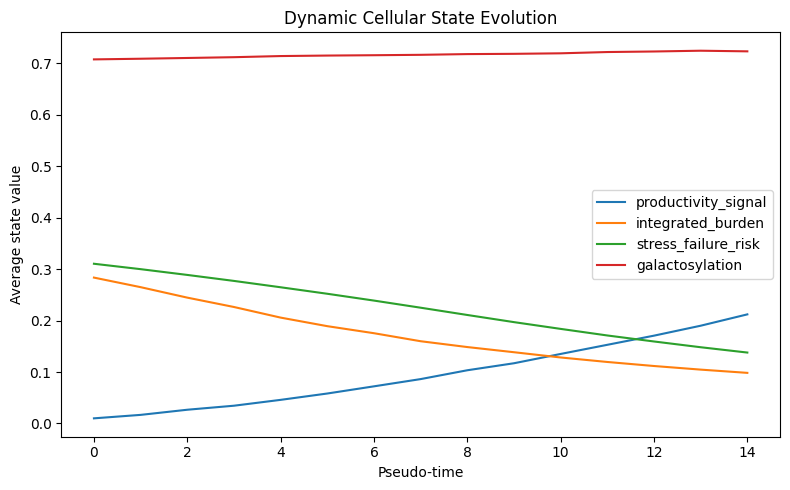

In [6]:
# --------------------------------------------------
# Section 6 — Average trajectory evolution
# --------------------------------------------------

avg_traj = (
    trajectory_df
    .groupby("pseudo_time")[
        [
            "productivity_signal",
            "integrated_burden",
            "stress_failure_risk",
            "galactosylation",
        ]
    ]
    .mean()
)

plt.figure(figsize=(8, 5))

for col in avg_traj.columns:
    plt.plot(avg_traj.index, avg_traj[col], label=col)

plt.xlabel("Pseudo-time")
plt.ylabel("Average state value")
plt.title("Dynamic Cellular State Evolution")

plt.legend()
plt.tight_layout()
plt.show()

## Section 7 — Compare archetype-specific trajectories

Different cellular archetypes may evolve differently.

This section compares dynamic trajectory behavior between archetypes.

Examples:

- resilient trajectories
- collapsing trajectories
- burden-accumulating trajectories
- quality-preserving trajectories

In [7]:
# --------------------------------------------------
# Section 7 — Archetype-specific dynamics
# --------------------------------------------------

archetype_summary = (
    trajectory_df
    .groupby(
        ["cellular_archetype", "pseudo_time"]
    )[
        [
            "productivity_signal",
            "integrated_burden",
            "stress_failure_risk",
        ]
    ]
    .mean()
    .reset_index()
)

display(archetype_summary.head())

,cellular_archetype,pseudo_time,productivity_signal,integrated_burden,stress_failure_risk
0,Balanced-Resilient,0,0.027099,0.124866,0.151090
1,Balanced-Resilient,1,0.047456,0.097015,0.131864
2,Balanced-Resilient,2,0.077604,0.070007,0.112989
3,Balanced-Resilient,3,0.098918,0.039197,0.095129
4,Balanced-Resilient,4,0.129249,0.020646,0.078172


## Section 8 — Visualize productivity trajectories by archetype

This section visualizes how productivity evolves differently across cellular archetypes.

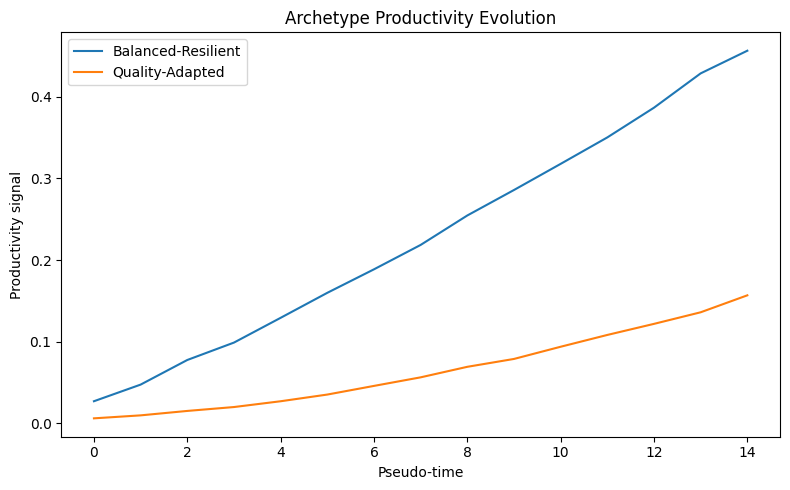

In [8]:
# --------------------------------------------------
# Section 8 — Productivity trajectory by archetype
# --------------------------------------------------

plt.figure(figsize=(8, 5))

for archetype in sorted(
    archetype_summary["cellular_archetype"].unique()
):

    subset = archetype_summary[
        archetype_summary["cellular_archetype"] == archetype
    ]

    plt.plot(
        subset["pseudo_time"],
        subset["productivity_signal"],
        label=archetype
    )

plt.xlabel("Pseudo-time")
plt.ylabel("Productivity signal")
plt.title("Archetype Productivity Evolution")

plt.legend()
plt.tight_layout()
plt.show()

## Section 9 — Simulate intervention rescue trajectories

This section simulates process intervention effects.

The intervention represents:

- adaptive feeding
- temperature shift
- perfusion rescue
- stress mitigation

The goal is to test whether stressed states can recover dynamically.

In [9]:
# --------------------------------------------------
# Section 9 — Rescue intervention simulation
# --------------------------------------------------

rescue_df = trajectory_df.copy()

rescue_mask = (
    rescue_df["pseudo_time"] >= 6
)

rescue_df.loc[rescue_mask, "integrated_burden"] *= 0.88
rescue_df.loc[rescue_mask, "stress_failure_risk"] *= 0.82

rescue_df.loc[rescue_mask, "productivity_signal"] *= 1.06
rescue_df.loc[rescue_mask, "galactosylation"] *= 1.05

display(
    rescue_df.head()
)

,clone_process_id,pseudo_time,cellular_archetype,productivity_signal,integrated_burden,oxidative_stress,er_stress_burden,stress_failure_risk,galactosylation,sialylation,overflow_burden,rescue_potential
0,0,0,Quality-Adapted,0.000000,0.553780,0.376073,0.673473,0.430073,0.768677,0.645732,0.557906,0.584229
1,0,1,Quality-Adapted,0.000000,0.529257,0.399048,0.696448,0.433167,0.758310,0.635365,0.570546,0.584229
2,0,2,Quality-Adapted,0.000000,0.537694,0.430925,0.728325,0.436682,0.758235,0.635290,0.596729,0.584229
3,0,3,Quality-Adapted,0.000000,0.521248,0.457873,0.755274,0.439376,0.754078,0.631133,0.617080,0.584229
4,0,4,Quality-Adapted,0.004812,0.515560,0.468865,0.766265,0.441784,0.738244,0.615299,0.633419,0.584229


## Section 10 — Compare rescue vs non-rescue trajectories

This section compares intervention trajectories against baseline trajectories.

The goal is to determine whether intervention stabilizes cellular states.

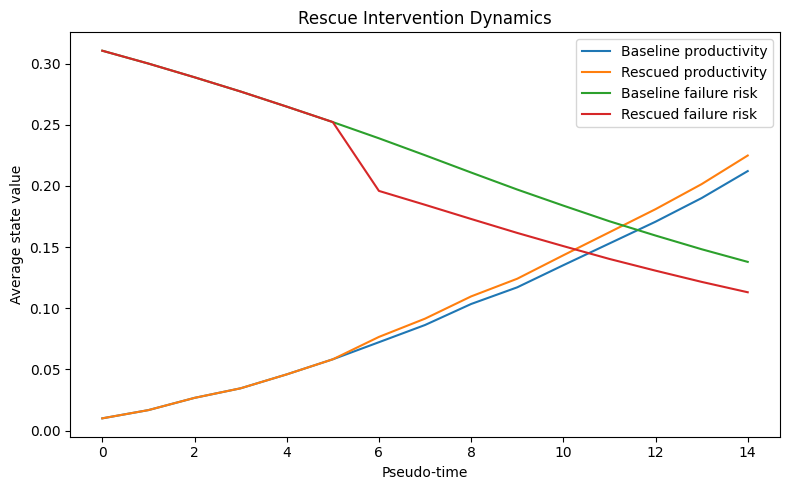

In [10]:
# --------------------------------------------------
# Section 10 — Rescue comparison
# --------------------------------------------------

baseline = (
    trajectory_df
    .groupby("pseudo_time")[
        [
            "productivity_signal",
            "stress_failure_risk",
        ]
    ]
    .mean()
)

rescued = (
    rescue_df
    .groupby("pseudo_time")[
        [
            "productivity_signal",
            "stress_failure_risk",
        ]
    ]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.plot(
    baseline.index,
    baseline["productivity_signal"],
    label="Baseline productivity"
)

plt.plot(
    rescued.index,
    rescued["productivity_signal"],
    label="Rescued productivity"
)

plt.plot(
    baseline.index,
    baseline["stress_failure_risk"],
    label="Baseline failure risk"
)

plt.plot(
    rescued.index,
    rescued["stress_failure_risk"],
    label="Rescued failure risk"
)

plt.xlabel("Pseudo-time")
plt.ylabel("Average state value")
plt.title("Rescue Intervention Dynamics")

plt.legend()
plt.tight_layout()
plt.show()

## Section 11 — Dynamic latent-state compression

This section compresses trajectory states into latent dynamic manifolds.

This approximates dynamic cellular-state landscapes.

In [11]:
# --------------------------------------------------
# Section 11 — Dynamic latent manifold
# --------------------------------------------------

latent_cols = [
    "productivity_signal",
    "integrated_burden",
    "oxidative_stress",
    "er_stress_burden",
    "stress_failure_risk",
    "galactosylation",
    "sialylation",
    "overflow_burden",
]

scaler = StandardScaler()

X = scaler.fit_transform(
    trajectory_df[latent_cols]
)

pca = PCA(n_components=2)

latent = pca.fit_transform(X)

trajectory_df["dynamic_latent_1"] = latent[:, 0]
trajectory_df["dynamic_latent_2"] = latent[:, 1]

print(
    pca.explained_variance_ratio_
)

[0.63316784 0.11033291]


## Section 12 — Visualize dynamic latent-state trajectories

This section visualizes evolving cellular trajectories in latent-state space.

Each point represents a cellular state at a specific pseudo-time.

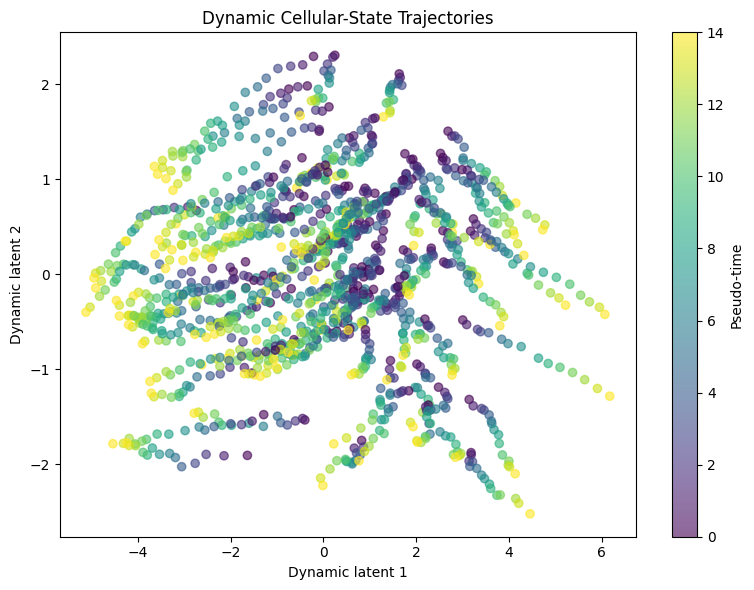

In [12]:
# --------------------------------------------------
# Section 12 — Dynamic latent-state visualization
# --------------------------------------------------

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    trajectory_df["dynamic_latent_1"],
    trajectory_df["dynamic_latent_2"],
    c=trajectory_df["pseudo_time"],
    alpha=0.6
)

plt.xlabel("Dynamic latent 1")
plt.ylabel("Dynamic latent 2")

plt.title("Dynamic Cellular-State Trajectories")

plt.colorbar(scatter, label="Pseudo-time")

plt.tight_layout()
plt.show()

## Section 13 — Identify dynamic trajectory regimes

This section clusters dynamic trajectories into temporal behavior regimes.

Examples:

- stable adaptive
- delayed collapse
- chronic stress
- rescued trajectory

In [13]:
# --------------------------------------------------
# Section 13 — Dynamic regime clustering
# --------------------------------------------------

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

trajectory_df["dynamic_regime"] = kmeans.fit_predict(
    trajectory_df[
        [
            "dynamic_latent_1",
            "dynamic_latent_2",
        ]
    ]
)

display(
    trajectory_df["dynamic_regime"]
    .value_counts()
)

dynamic_regime
1    503
2    345
3    269
0    263
Name: count, dtype: int64

## Section 14 — Characterize dynamic regimes

This section summarizes the biological meaning of each dynamic trajectory regime.

In [14]:
# --------------------------------------------------
# Section 14 — Dynamic regime characterization
# --------------------------------------------------

regime_summary = (
    trajectory_df
    .groupby("dynamic_regime")[
        [
            "productivity_signal",
            "integrated_burden",
            "stress_failure_risk",
            "galactosylation",
            "overflow_burden",
        ]
    ]
    .mean()
    .round(3)
)

display(regime_summary)

,productivity_signal,integrated_burden,stress_failure_risk,galactosylation,overflow_burden
dynamic_regime,,,,,
0,0.279,0.005,0.022,0.813,0.175
1,0.034,0.221,0.274,0.710,0.362
2,0.112,0.076,0.146,0.777,0.282
3,0.009,0.373,0.430,0.559,0.543


## Section 15 — Export dynamic trajectory dataset

This section exports Notebook14 outputs.

These outputs can later support:

- RL environments
- adaptive process control
- SDL simulation
- dynamic digital twins

In [15]:
# --------------------------------------------------
# Section 15 — Export outputs
# --------------------------------------------------

OUT_DIR = (
    ROOT /
    "data" /
    "synthetic" /
    "digital_twin"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRAJ_PATH = (
    OUT_DIR /
    f"notebook14_dynamic_trajectory_{n_clones}_{scenario}.csv"
)

REGIME_PATH = (
    OUT_DIR /
    f"notebook14_dynamic_regime_summary_{n_clones}_{scenario}.csv"
)

trajectory_df.to_csv(
    TRAJ_PATH,
    index=False
)

regime_summary.to_csv(
    REGIME_PATH
)

print("Saved:")
print(TRAJ_PATH)
print(REGIME_PATH)

Saved:
/Users/sang/CLD_ML_PIPELINE/data/synthetic/digital_twin/notebook14_dynamic_trajectory_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/digital_twin/notebook14_dynamic_regime_summary_5000_legacy.csv


# Final Summary — Notebook14

Notebook14 introduced dynamic temporal cellular-state evolution into the virtual CHO-cell simulator.

Previous notebooks modeled:

- productivity
- burden
- glycosylation
- process realism
- omics latent states

Notebook14 extended these concepts into dynamic biological trajectories.

---

# Major additions in Notebook14

The notebook introduced:

- pseudo-time cellular evolution
- dynamic burden accumulation
- stress adaptation trajectories
- productivity collapse/recovery
- glycosylation drift
- intervention rescue simulation
- latent trajectory manifolds
- dynamic regime discovery

This transformed the simulator from:

static latent-state prediction

into:

dynamic evolving digital-twin simulation.

---

# Biological significance

Notebook14 approximates how real CHO cells evolve during culture.

The simulator now models:

clone + process + time
→ evolving cellular state
→ dynamic manufacturing outcome

This is substantially closer to real bioprocess behavior.

---

# Dynamic trajectory interpretation

The notebook identified multiple temporal trajectory regimes, including:

- stable adaptive states
- stress-accumulating states
- delayed collapse trajectories
- intervention-rescued trajectories

These dynamic regimes are biologically meaningful because real manufacturing performance depends on temporal state evolution, not only static measurements.

---

# Digital twin significance

Notebook14 establishes the first true digital-twin behavior layer in the project.

The simulator now supports:

- temporal state evolution
- adaptive interventions
- trajectory-based optimization
- future RL environments
- self-driving laboratory architectures

This notebook forms the foundation for future:

- reinforcement learning
- closed-loop optimization
- adaptive process control
- autonomous process development

---

# Important limitation

The trajectories remain synthetic latent approximations.

They are not mechanistic ODE-based kinetics or experimentally validated trajectories.

However, the trajectory logic is biologically motivated and structurally coherent.

Future versions can introduce:

- empirical time-course calibration
- metabolomic kinetics
- dynamic feeding schedules
- mechanistic process models
- RL-driven intervention policies

---

# Strategic significance

The project is no longer only a clone-selection simulator.

It is evolving toward:

a dynamic virtual CHO-cell manufacturing intelligence platform.

This architecture resembles future autonomous biologics development systems.

---

# References

## CHO systems biology and omics

- Hefzi H et al. (2016)
  A Consensus Genome-scale Reconstruction of Chinese Hamster Ovary Cell Metabolism.
  Cell Systems.

- Lewis NE et al. (2013)
  Omics analyses of Chinese hamster ovary cells.
  Current Opinion in Biotechnology.

- Richelle A & Lewis NE (2017)
  Improvements in protein production in mammalian cells from targeted metabolic engineering.
  Current Opinion in Systems Biology.

---

## Glycosylation and process burden

- Gramer MJ et al. (2011)
  Modulation of antibody galactosylation through feeding strategies in CHO cells.
  Biotechnology and Bioengineering.

- Hossler P et al. (2009)
  Protein glycosylation in mammalian cell culture.
  Glycobiology.

---

## Digital twins and bioprocess systems

- Herwig C et al. (2021)
  Digital Twins in Biopharmaceutical Process Development and Manufacturing.
  Trends in Biotechnology.

- Narciso-da-Rocha C et al. (2023)
  Digital Twins for Bioprocess Optimization.
  Biotechnology Advances.

---

## Reinforcement learning and self-driving laboratories

- Häse F et al. (2019)
  Phoenics: Bayesian optimizer for chemistry.
  ACS Central Science.

- Angermueller C et al. (2016)
  Deep learning for computational biology.
  Molecular Systems Biology.

- Burger B et al. (2020)
  A mobile robotic chemist.
  Nature.